In [ ]:
from datasets import generate_baseline_problems_and_distractors
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# out of the viable nodes that can be flipped, how many nodes will be flipped
nr_problems = 100
nr_numerical_instantiations = 5

seed = 14

## Inspect: Baseline Problems and Distractors

In [3]:
dataset = generate_baseline_problems_and_distractors(nr_problems=nr_problems, nr_numerical_instantiations=nr_numerical_instantiations, 
                                                     reduce_nonlinearity=True, prob_misconcievable=0.5, partwhole_start_chance=0.33, seed=seed)

In [ ]:
dataset

### Stats about the DS

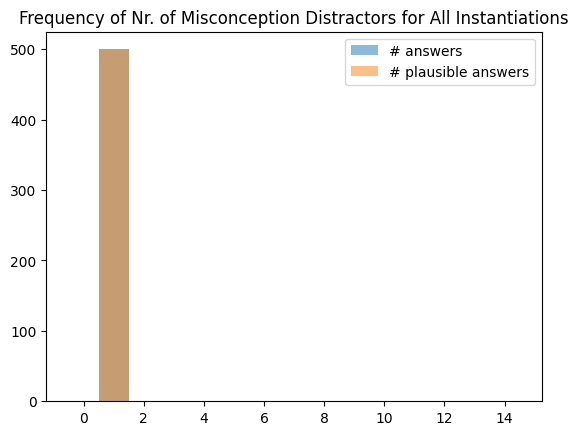

In [5]:
plt.title("Frequency of Nr. of Misconception Distractors for All Instantiations")
plt.hist([len(mwp["instantiations"][num_inst]["misconception_answers"]) for mwp in dataset.values() for num_inst in mwp["instantiations"]], bins=list(range(16)), label="# answers", align="left", alpha=0.5)
plt.hist([len([a for a in mwp["instantiations"][num_inst]["misconception_answers"] if a["plausible"]]) for mwp in dataset.values() for num_inst in mwp["instantiations"]], bins=list(range(16)), label="# plausible answers", align="left", alpha=0.5)
plt.legend()

# total misconception distractors = 500
# unique misconception distractors = 136
# misconception distractors < 2 = 0
# misconception distractors > 1000 = 0
# fractional misconception distractors = 0
min misconception distractors = 15
max misconception distractors = 232
# instantiations = 500
# instantiations with at least one plausible distractor = 500
# plausible misconception distractors = 500
# implausible misconception distractors = 0
# partwhole mwps = 24
# avg number of flips / avg number of eligible = 1.0 / 1.74
# ratio chosen inconsistent / eligible = 0.6925


(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,  74., 312., 114.,   0.,
          0.,   0.,   0.,   0.]),
 array([-1.e+04, -5.e+03, -1.e+03, -5.e+02, -1.e+02, -5.e+01, -1.e+01,
         1.e+01,  5.e+01,  1.e+02,  5.e+02,  1.e+03,  5.e+03,  1.e+04,
         1.e+06,  1.e+07]),
 <BarContainer object of 15 artists>)

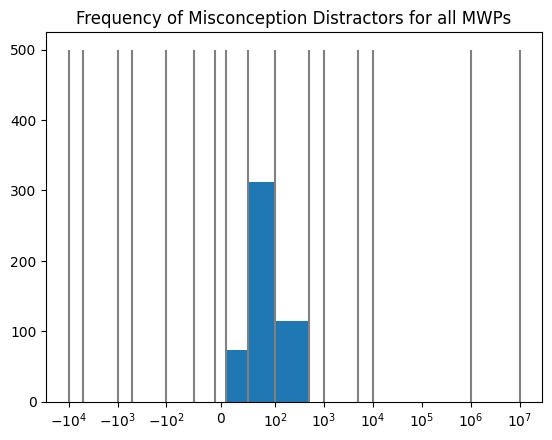

In [12]:
plt.title("Frequency of Misconception Distractors for all MWPs")
num_mis_distr_grouped_by_inst = [[a["answer"] for a in mwp["instantiations"][i]["misconception_answers"]] for mwp in dataset.values() for i in mwp["instantiations"].keys()]
all_mis_distr = [a["answer"] for mwp in dataset.values() for i in mwp["instantiations"].keys() for a in mwp["instantiations"][i]["misconception_answers"]]
all_mis_distr_plausibilities = [a["plausible"] for mwp in dataset.values() for i in mwp["instantiations"].keys() for a in mwp["instantiations"][i]["misconception_answers"]]
print(f"# total misconception distractors = {len(all_mis_distr)}")
print(f"# unique misconception distractors = {len(np.unique(all_mis_distr))}")
print(f"# misconception distractors < 2 = {len(list(filter(lambda x: x < 2, all_mis_distr)))}")
print(f"# misconception distractors > 1000 = {len(list(filter(lambda x: x > 1000, all_mis_distr)))}")
print(f"# fractional misconception distractors = {len(list(filter(lambda x: int(x) != x, all_mis_distr)))}")
print(f"min misconception distractors = {min(all_mis_distr)}")
print(f"max misconception distractors = {max(all_mis_distr)}")
print(f"# instantiations = {len(num_mis_distr_grouped_by_inst)}")
print(f"# instantiations with at least one plausible distractor = {len(list(filter(lambda x: any(a >= 2 and int(a) == a for a in x), num_mis_distr_grouped_by_inst)))}")
print(f"# plausible misconception distractors = {len([p for p in all_mis_distr_plausibilities if p])}")
print(f"# implausible misconception distractors = {len([p for p in all_mis_distr_plausibilities if not p])}")
print(f"# partwhole mwps = {len([dataset[mwp_id] for mwp_id in dataset if dataset[mwp_id]['metadata']['rule_count'].get('ContPartWhole', 0) > 0])}")

# NOTE: can be higher > p_misconcievable bc we retry if 0
print(f"# avg number of flips / avg number of eligible = {np.mean([len(dataset[mwp_id]['metadata']['inconsistent_conclusions']) for mwp_id in dataset])} / {np.mean([dataset[mwp_id]['metadata']['rule_count'].get('ContTransferCont', 0) + dataset[mwp_id]['metadata']['rule_count'].get('ContCompCont', 0) for mwp_id in dataset])}")
print(f"# ratio chosen inconsistent / eligible = {np.mean([len(dataset[mwp_id]['metadata']['inconsistent_conclusions'])/(dataset[mwp_id]['metadata']['rule_count'].get('ContTransferCont', 0) + dataset[mwp_id]['metadata']['rule_count'].get('ContCompCont', 0)) for mwp_id in dataset])}")

plt.xscale("symlog", linthresh=100)
bins = [-10000, -5000, -1000, -500, -100, -50, -10, 10, 50, 100, 500, 1000, 5000, 10000, 10e5, 10e6]
plt.vlines(bins, ymin=0, ymax=500, color="gray")
plt.hist(all_mis_distr, bins=bins)

(array([24., 19., 21., 12.,  0., 13.,  5.,  2.,  2.,  2.]),
 array([ 2. ,  2.8,  3.6,  4.4,  5.2,  6. ,  6.8,  7.6,  8.4,  9.2, 10. ]),
 <BarContainer object of 10 artists>)

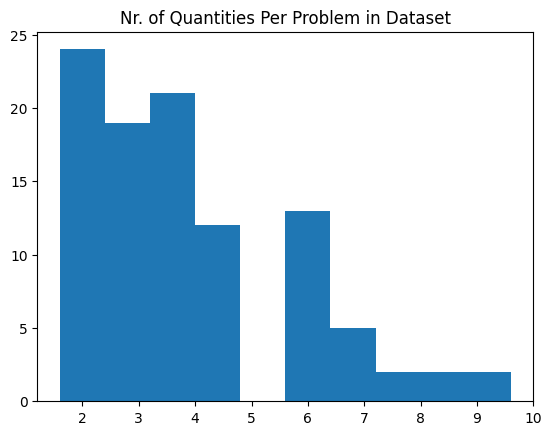

In [8]:
plt.title("Nr. of Quantities Per Problem in Dataset")
numbers_per_problem = [len(dataset[mwp_id]["instantiations"][0]["instantiation"]) for mwp_id in dataset]
plt.hist(numbers_per_problem, align="left")

In [11]:
for mwp_id in dataset:
    for num_inst in dataset[mwp_id]["instantiations"]:
        if num_inst == 0:
            print(dataset[mwp_id]["instantiations"][num_inst]["problem"])
            print()

Grace has 68 apples. Then Harper gets 6 of Grace's apples. Henry has 10 apples. Sophia has 3 apples. At this moment, the number of apples that Abigail has more than Grace is equal to the difference in the number of apples that Henry has compared to Sophia. John has 52 bananas. Then John buys 8 more bananas from Michael. Then John buys 22 more bananas from Matthew. How many fruits do Abigail and John have combined?

Evelyn has 67 black watches. Then Evelyn gives away 6 black watches to Jackson. Then Ella buys 22 of Evelyn's black watches. How many black watches does Evelyn have?

Isabella has 55 vases. Then Ava gets 22 of Isabella's vases. How many vases does Isabella have?

Alexander has 68 huge hairdryers. If we were to take away 3 huge hairdryers from Grace now, then Grace would have as many huge hairdryers as Joseph. At this moment, the number of huge hairdryers that Alexander has more than Hannah is equal to the difference in the number of huge hairdryers that Grace has compared to